# IEEE Demo Ready - Brain Tumor Detection using EfficientNetB3

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [7]:

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import os, re


In [8]:

IMG_SIZE = (224,224)
BATCH_SIZE = 40
EPOCHS = 50
DATASET_PATH = "/kaggle/input/brain-tumor-mri-dataset/Training"
TEST_PATH = "/kaggle/input/brain-tumor-mri-dataset/Testing"


In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=40,
    class_mode='categorical',
    shuffle=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

valid_gen = valid_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=40,
    class_mode='categorical',
    shuffle=False
)


Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [10]:

base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='max'
)

base_model.trainable = True

x = base_model.output
x = layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.016))(x)
x = layers.Dropout(0.45)(x)

outputs = layers.Dense(len(train_gen.class_indices), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,184,179 (42.66 MB)

 Trainable params: 11,093,804 (42.32 MB)

 Non-trainable params: 90,375 (353.03 KB)

In [11]:

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 269s 978ms/step - accuracy: 0.8198 - loss: 6.1139 - val_accuracy: 0.3006 - val_loss: 5.7135 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 670ms/step - accuracy: 0.9332 - loss: 3.7405 - val_accuracy: 0.3119 - val_loss: 4.2764 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 94s 667ms/step - accuracy: 0.9530 - loss: 2.3929 - val_accuracy: 0.2500 - val_loss: 6.9649 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.9694 - loss: 1.6761
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
140/140 ━━━━━━━━━━━━━━━━━━━━ 93s 667ms/step - accuracy: 0.9750 - loss: 1.4951 - val_accuracy: 0.2512 - val_loss: 7.2558 - learning_rate: 0.0010
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 680ms/step - accuracy: 0.9846 - loss: 1.0724 - val_accuracy: 0.8794 - val_loss: 1.3383 - learning_rate: 3.0000e-04
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 95s 679ms/step - accuracy: 

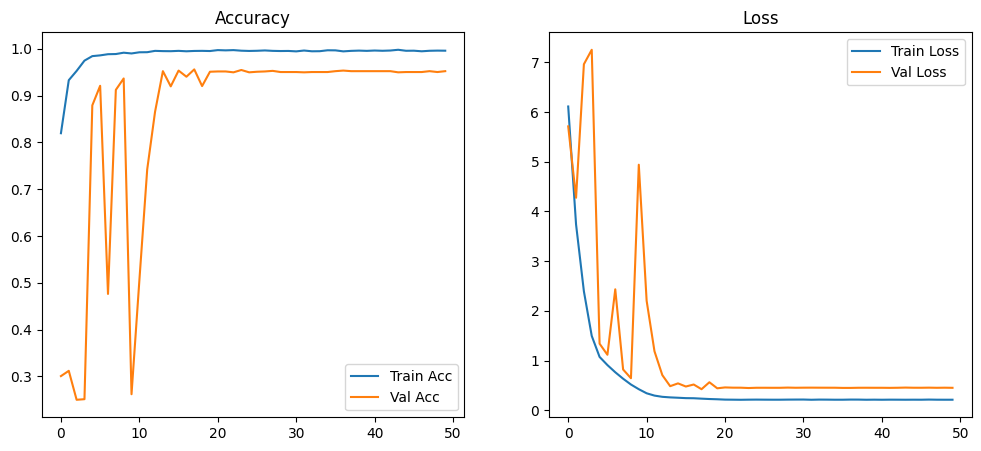

In [12]:

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(acc, label='Train Acc')
    plt.plot(val_acc, label='Val Acc')
    plt.legend()
    plt.title("Accuracy")

    plt.subplot(1,2,2)
    plt.plot(loss, label='Train Loss')
    plt.plot(val_loss, label='Val Loss')
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_history(history)


In [13]:

test_gen = valid_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=40,
    class_mode='categorical',
    shuffle=False
)

test_score = model.evaluate(test_gen, verbose=1)
print("Test Accuracy:", test_score[1]*100)
print(train_gen.class_indices)
print(test_gen.class_indices)


Found 1600 images belonging to 4 classes.
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.9525 - loss: 0.4501
Test Accuracy: 95.24999856948853
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [14]:

test_gen.reset()
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
print(y_pred[:10])


40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step
[2 0 0 1 2 0 0 0 1 0]


In [15]:

model_name = "EfficientNetB3-BrainTumor"
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

def get_version():
    files = os.listdir(save_dir)
    versions = [int(re.search(r'v(\d+)', f).group(1))
                for f in files if re.search(r'v(\d+)', f)]
    return max(versions)+1 if versions else 1

v = get_version()
acc = test_score[1] * 100

model_path = f"{save_dir}/{model_name}-v{v}-{acc:.2f}.keras"
weights_path = f"{save_dir}/{model_name}-v{v}.weights.h5"

model.save(model_path)
model.save_weights(weights_path)

print("Saved:", model_path)


Saved: saved_models/EfficientNetB3-BrainTumor-v1-95.25.keras


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step


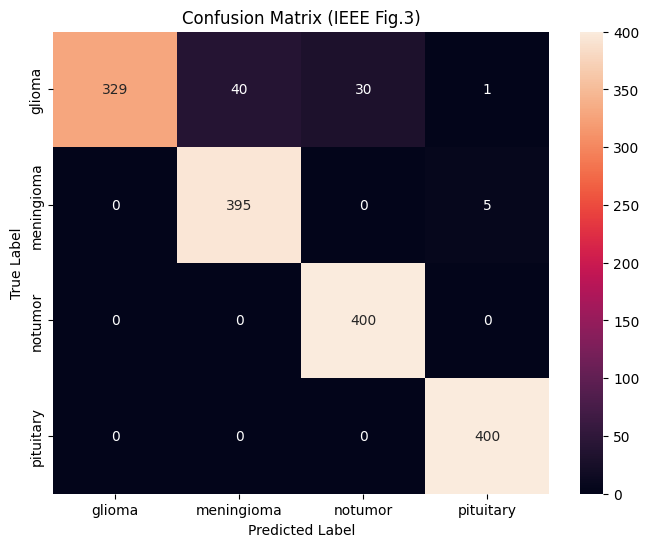

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = test_gen.classes

# Predictions
test_gen.reset()
preds = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

# Class labels
class_labels = list(test_gen.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (IEEE Fig.3)")
plt.show()

In [18]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.82      0.90       400
  meningioma       0.91      0.99      0.95       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



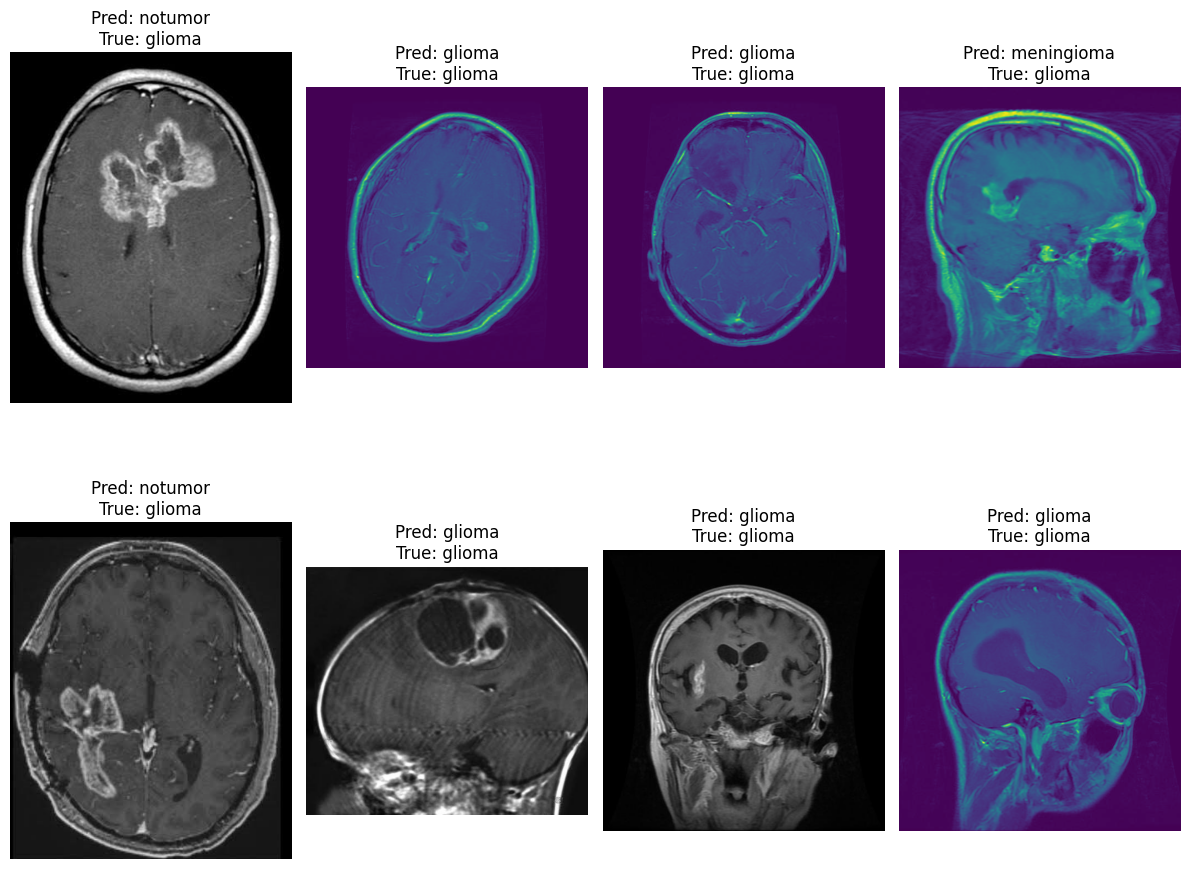

In [19]:
import matplotlib.pyplot as plt

# Get file paths
file_paths = test_gen.filepaths

# Show 8 predictions
plt.figure(figsize=(12,10))

for i in range(8):
    img = plt.imread(file_paths[i])

    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.axis('off')

    true_label = class_labels[y_true[i]]
    pred_label = class_labels[y_pred[i]]

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")

plt.tight_layout()
plt.show()

In [20]:
for i in range(8):
    true_label = class_labels[y_true[i]]
    pred_label = class_labels[y_pred[i]]

    if true_label == pred_label:
        status = "✅"
    else:
        status = "❌"

    print(f"{status} Pred: {pred_label} | True: {true_label}")

❌ Pred: notumor | True: glioma
✅ Pred: glioma | True: glioma
✅ Pred: glioma | True: glioma
❌ Pred: meningioma | True: glioma
❌ Pred: notumor | True: glioma
✅ Pred: glioma | True: glioma
✅ Pred: glioma | True: glioma
✅ Pred: glioma | True: glioma
